# Credit Card Default Prediction (UCI Dataset)

## Objective
Predict whether a credit card customer will default next month using multiple
machine learning models. Each model is evaluated **independently**, and a final
performance leaderboard is shown at the end.

## 1. Imports & Environment Setup
This section imports all required libraries and sets reproducibility.
Libraries are grouped by purpose for clarity.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

%matplotlib inline

## 2. Load Dataset
Load the UCI Credit Card Default dataset. The `ID` column is removed
because it has no predictive value.

In [2]:
DATA_PATH = '/content/UCI_Credit_Card.csv'

try:
    df = pd.read_csv(DATA_PATH)
    print('Dataset loaded successfully')
except FileNotFoundError:
    raise Exception('Please upload UCI_Credit_Card.csv to Colab')

df.drop(columns=['ID'], inplace=True)

Dataset loaded successfully


## 3. Data Exploration
Quick inspection to understand dataset structure and target imbalance.

In [3]:
print('Dataset Shape:', df.shape)
display(df.head())

print('\nTarget Distribution:')
display(df['default.payment.next.month'].value_counts(normalize=True))

Dataset Shape: (30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0



Target Distribution:


,proportion
default.payment.next.month,
0,0.7788
1,0.2212


## 4. Data Cleaning
Fix known inconsistencies in categorical features.

In [4]:
df['EDUCATION'] = df['EDUCATION'].replace([0, 4, 5, 6], 4)
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)

## 5. Feature Engineering
Create financial behavior, trend, and risk-related features.

In [5]:
bill_cols = [f'BILL_AMT{i}' for i in range(1, 7)]
pay_cols = [f'PAY_AMT{i}' for i in range(1, 7)]
delay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

df['TOTAL_BILL_AMT'] = df[bill_cols].sum(axis=1)
df['TOTAL_PAY_AMT'] = df[pay_cols].sum(axis=1)
df['PAY_RATIO'] = df['TOTAL_PAY_AMT'] / (df['TOTAL_BILL_AMT'] + 1)

df['BILL_TREND'] = df['BILL_AMT1'] - df['BILL_AMT6']
df['AVG_PAY_DELAY'] = df[delay_cols].mean(axis=1)
df['DELAY_TREND'] = df['PAY_0'] - df['PAY_6']
df['PAY_VOLATILITY'] = df[pay_cols].std(axis=1)

df['UTILIZATION'] = df['BILL_AMT1'] / (df['LIMIT_BAL'] + 1)

## 6. Train–Test Split
Stratified split to preserve class imbalance.

In [6]:
X = df.drop(columns=['default.payment.next.month'])
y = df['default.payment.next.month']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (24000, 31)
Test shape: (6000, 31)


## 7. Single Model Evaluation Function
Each model is trained and evaluated **independently**.
The function prints a classification report and confusion matrix
and returns metrics for the final leaderboard.

In [7]:
def evaluate_single_model(model, model_name, threshold=0.45):
    print('=' * 70)
    print(f'MODEL: {model_name}')
    print('=' * 70)

    pipeline = ImbPipeline([
        ('scaler', RobustScaler()),
        ('pca', PCA(n_components=15)),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)

    y_prob = pipeline.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    print('\nClassification Report')
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    print('Confusion Matrix')
    print(cm)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} – Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

## 8. Model Evaluations (One Model per Cell)
Run each model in its own cell for clean, isolated output.

8.1 Logistic Regression

MODEL: Logistic Regression

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.53      0.65      4673
           1       0.30      0.71      0.42      1327

    accuracy                           0.57      6000
   macro avg       0.58      0.62      0.54      6000
weighted avg       0.74      0.57      0.60      6000

Confusion Matrix
[[2456 2217]
 [ 385  942]]


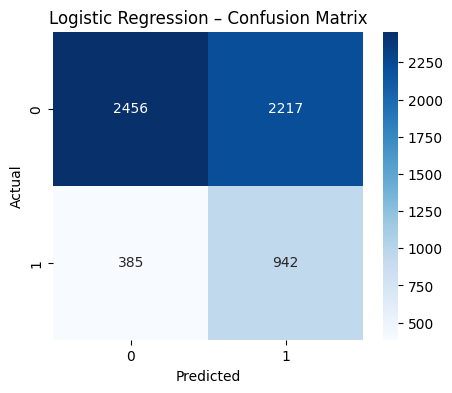

In [8]:
lr_results = evaluate_single_model(
    LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Logistic Regression'
)

8.2 Random Forest

MODEL: Random Forest

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      4673
           1       0.45      0.62      0.52      1327

    accuracy                           0.75      6000
   macro avg       0.66      0.70      0.67      6000
weighted avg       0.78      0.75      0.76      6000

Confusion Matrix
[[3652 1021]
 [ 502  825]]


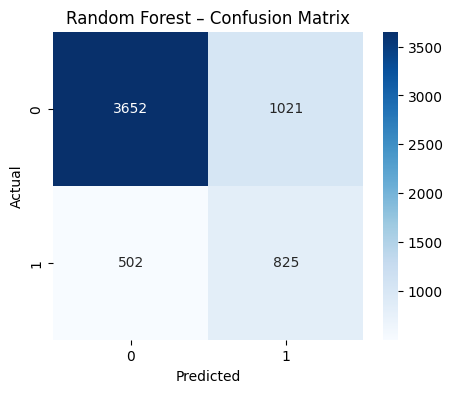

In [9]:
rf_results = evaluate_single_model(
    RandomForestClassifier(
        n_estimators=200, max_depth=12,
        class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Random Forest'
)

8.3 Gradient Boosting

MODEL: Gradient Boosting

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.74      0.80      4673
           1       0.41      0.66      0.51      1327

    accuracy                           0.72      6000
   macro avg       0.65      0.70      0.66      6000
weighted avg       0.78      0.72      0.74      6000

Confusion Matrix
[[3442 1231]
 [ 454  873]]


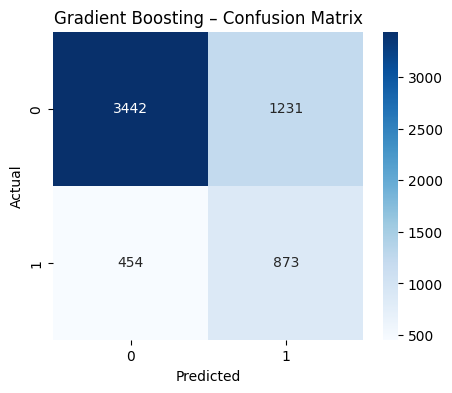

In [10]:
gb_results = evaluate_single_model(
    GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1,
        max_depth=5, random_state=RANDOM_STATE
    ),
    'Gradient Boosting'
)

8.4  KNN

MODEL: KNN

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.61      0.72      4673
           1       0.34      0.71      0.46      1327

    accuracy                           0.63      6000
   macro avg       0.61      0.66      0.59      6000
weighted avg       0.76      0.63      0.66      6000

Confusion Matrix
[[2860 1813]
 [ 391  936]]


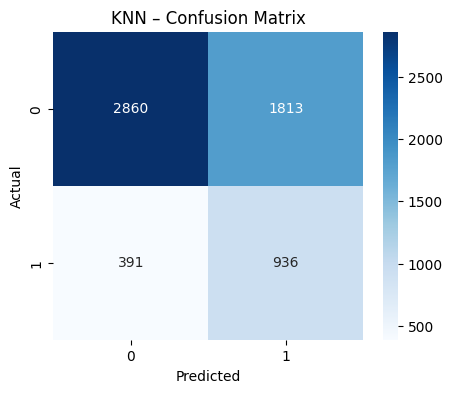

In [11]:
knn_results = evaluate_single_model(
    KNeighborsClassifier(n_neighbors=21),
    'KNN'
)

8.5 Naive Bayes

MODEL: Naive Bayes

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.10      0.18      4673
           1       0.23      0.96      0.37      1327

    accuracy                           0.29      6000
   macro avg       0.57      0.53      0.28      6000
weighted avg       0.75      0.29      0.23      6000

Confusion Matrix
[[ 480 4193]
 [  54 1273]]


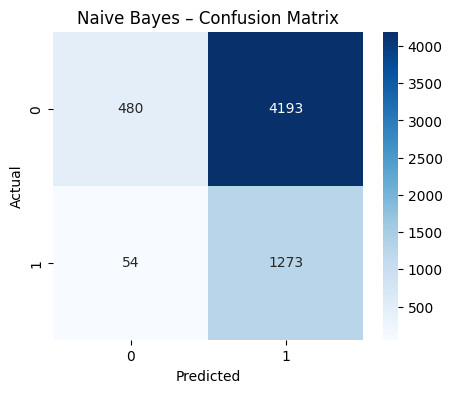

In [12]:
nb_results = evaluate_single_model(
    GaussianNB(),
    'Naive Bayes'
)

## 9. Final Performance Leaderboard
All models are compared **only here**.

In [13]:
results_df = pd.DataFrame([
    lr_results, rf_results, gb_results, knn_results, nb_results
])

results_df = results_df.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
results_df.index += 1

display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Random Forest,0.746167,0.446912,0.621703,0.520013,0.764110
2,Gradient Boosting,0.719167,0.414924,0.657875,0.508890,0.760602
3,KNN,0.632667,0.340487,0.705350,0.459274,0.729383
4,Logistic Regression,0.566333,0.298196,0.709872,0.419973,0.712080
5,Naive Bayes,0.292167,0.232894,0.959307,0.374798,0.711415


## 10. Final Visualization
Bar chart comparing models by F1-score.

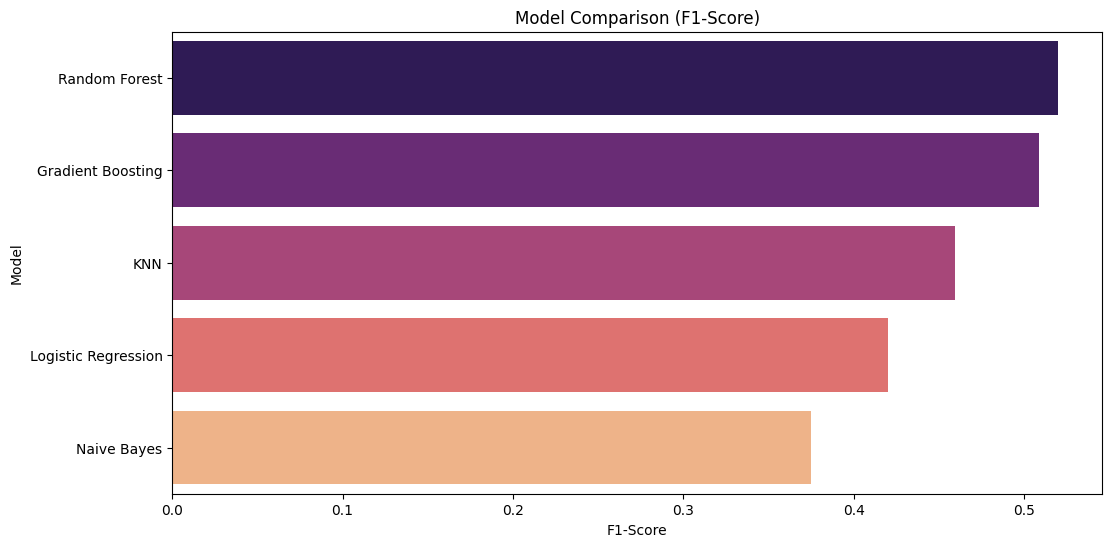

In [14]:
plt.figure(figsize=(12, 6))
sns.barplot(x='F1-Score', y='Model', data=results_df, palette='magma')
plt.title('Model Comparison (F1-Score)')
plt.xlabel('F1-Score')
plt.ylabel('Model')
plt.show()